# Part 1:

For this week’s mini-project, you will participate in this Kaggle competition:  

[Kaggle Competition: BBC News Classification](https://www.kaggle.com/competitions/learn-ai-bbc/overview)

This Kaggle competition is about categorizing news articles. You will use matrix factorization to predict the category and submit your notebook for peer evaluation. 

### Step 1
  
### Extracting word features and show Exploratory Data Analysis (EDA) — Inspect, Visualize and Clean the Data

Show a few visualizations like histograms. Describe any data cleaning procedures. Based on your EDA, what is your plan of analysis? 

Please feel free to look at online resources on processing raw texts to feature vectors. Many methods process texts to matrix form (word embedding), including TF-IDF, GloVe, Word2Vec, etc. Pick a method and process the raw texts to word embedding. Briefly explain the method(s) and how they work in your own words. Also, do exploratory data analysis such as word statistics and/or visualization.

As we did not learn natural language processing (NLP) specific techniques such as word embeddings in the lectures, we recommend reading discussions and example codes from others in the Kaggle and/or doing some research online to make sure you understand. You can refer to any resource as needed, but make sure you “demonstrate” your understanding- please include explaining in your own words, discussions, and your interpretation. Also importantly, please have a reference list at the end of the report. 

In [1]:
# Libraries
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import nltk
import seaborn as sns
import ssl

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.decomposition import TruncatedSVD, NMF
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import chi2
from sklearn.linear_model import LogisticRegression
from sklearn.manifold import TSNE
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, StratifiedShuffleSplit 
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.svm import LinearSVC

In [2]:
# Global variables
MIN_DF = 5
RANDOM_STATE = 42

In [3]:
# Load the data
train_df = pd.read_csv('data/BBC_News_Train.csv')
test_df = pd.read_csv('data/BBC_News_Test.csv')
sample_solution_df = pd.read_csv('data/BBC_News_Sample_Solution.csv')

print("Exploratory Data Analysis (EDA)")
print(f"Training data shape: {train_df.shape}")
print(f"Test data shape: {test_df.shape}")
print(f"\nTraining data columns: {train_df.columns.tolist()}")
print(f"Test data columns: {test_df.columns.tolist()}")

# Basic info about the training dataset
print(f"\nTraining data info:")
print(train_df.info)

print(f"\nData types:")
print(train_df.dtypes.value_counts())

print(f"\nMissing values in training data:")
print(train_df.isnull().sum())

print(f"\nAdding category_id:")
train_df['category_id'] = train_df.Category.factorize()[0]
display(train_df)

Exploratory Data Analysis (EDA)
Training data shape: (1490, 3)
Test data shape: (735, 2)

Training data columns: ['ArticleId', 'Text', 'Category']
Test data columns: ['ArticleId', 'Text']

Training data info:
<bound method DataFrame.info of       ArticleId                                               Text  \
0          1833  worldcom ex-boss launches defence lawyers defe...   
1           154  german business confidence slides german busin...   
2          1101  bbc poll indicates economic gloom citizens in ...   
3          1976  lifestyle  governs mobile choice  faster  bett...   
4           917  enron bosses in $168m payout eighteen former e...   
...         ...                                                ...   
1485        857  double eviction from big brother model caprice...   
1486        325  dj double act revamp chart show dj duo jk and ...   
1487       1590  weak dollar hits reuters revenues at media gro...   
1488       1587  apple ipod family expands market apple has

,ArticleId,Text,Category,category_id
0,1833,worldcom ex-boss launches defence lawyers defe...,business,0
1,154,german business confidence slides german busin...,business,0
2,1101,bbc poll indicates economic gloom citizens in ...,business,0
3,1976,lifestyle governs mobile choice faster bett...,tech,1
4,917,enron bosses in $168m payout eighteen former e...,business,0
...,...,...,...,...
1485,857,double eviction from big brother model caprice...,entertainment,4
1486,325,dj double act revamp chart show dj duo jk and ...,entertainment,4
1487,1590,weak dollar hits reuters revenues at media gro...,business,0
1488,1587,apple ipod family expands market apple has exp...,tech,1


In [4]:
# Let's get the mappings for Category to category_id and vise versa

# Mapping for Category to category_id for modeling.
category_to_id = dict(
    train_df[['Category', 'category_id']].drop_duplicates().sort_values('category_id').values
)
print(f"category_to_id: {category_to_id}")
# Let's get the mapping for category_id to Category for modeling.
id_to_category = dict(
    train_df[['category_id','Category']].drop_duplicates().sort_values('category_id').values
)
print(f"id_to_category: {id_to_category}")

category_to_id: {'business': 0, 'tech': 1, 'politics': 2, 'sport': 3, 'entertainment': 4}
id_to_category: {0: 'business', 1: 'tech', 2: 'politics', 3: 'sport', 4: 'entertainment'}


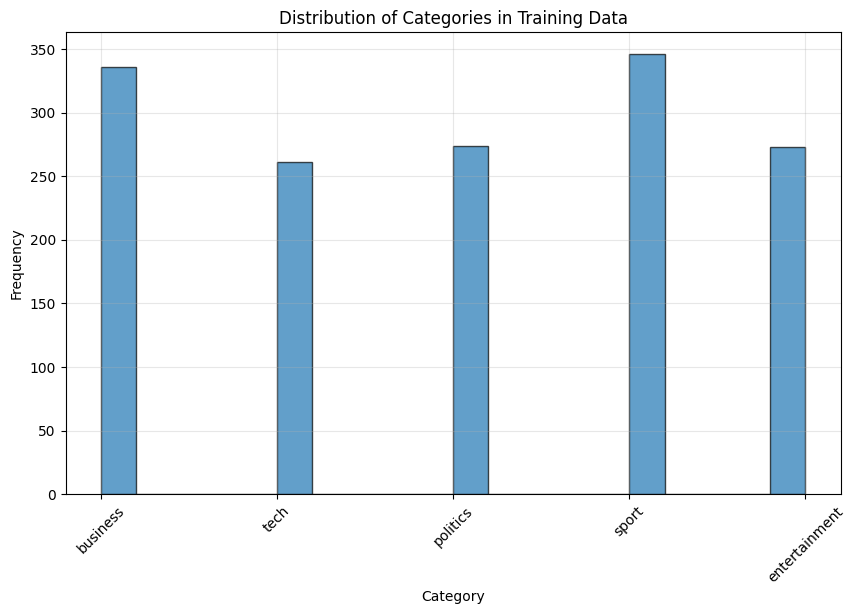

In [5]:
# Create histogram for the distribution of categories
plt.figure(figsize=(10, 6))
plt.hist(train_df['Category'], bins=20, edgecolor='black', alpha=0.7)
plt.title('Distribution of Categories in Training Data')
plt.xlabel('Category')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

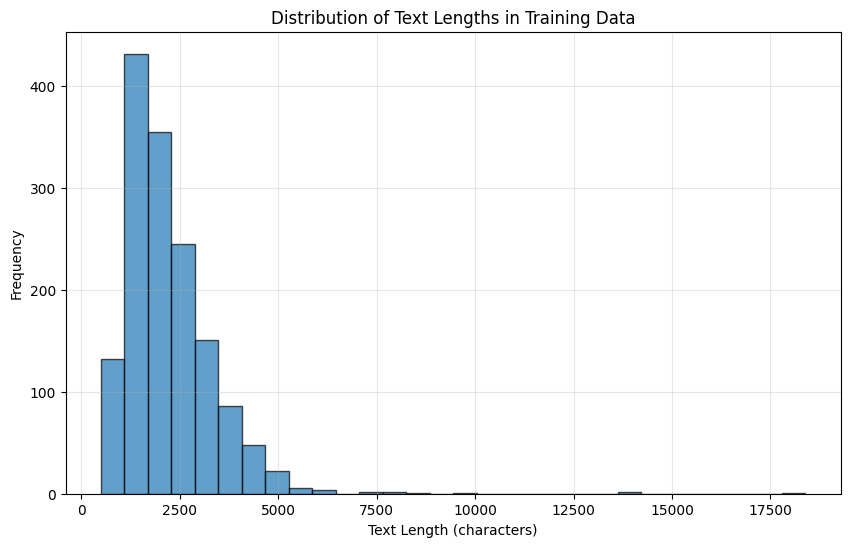

In [6]:
# Create histogram for the distribution of the length of each text
text_lengths = train_df['Text'].str.len()

# Create histogram of text lengths
plt.figure(figsize=(10, 6))
plt.hist(text_lengths, bins=30, edgecolor='black', alpha=0.7)
plt.title('Distribution of Text Lengths in Training Data')
plt.xlabel('Text Length (characters)')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)

In [7]:
# Workaround for importing stopwords
try:
    _create_unverified_https_context = ssl._create_unverified_context
except AttributeError:
    pass
else:
    ssl._create_default_https_context = _create_unverified_https_context

nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('wordnet')
nltk.download('stopwords')

# Helper function for preprocessing text
# Ensure Text is string and handle missing values and whitespaces.
def preprocess_text(text):
    stop_words = set(stopwords.words('english'))
    lemmatizer = WordNetLemmatizer()
    tokens = word_tokenize(text)
    tokens = [lemmatizer.lemmatize(word.lower()) for word in tokens if word.isalpha() and word.lower() not in stop_words]
    return ' '.join(tokens)

# Process text on both datasets and store them as 'processed_text' for reusability 
train_df['processed_text'] = train_df['Text'].apply(preprocess_text)
test_df['processed_text'] = test_df['Text'].apply(preprocess_text)

[nltk_data] Downloading package punkt to /Users/drivera53/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/drivera53/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/drivera53/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/drivera53/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [8]:
# Transform raw text into numerical features
# Vectorize: unigrams + bigrams, English stopwords, l2 norm, sublinear TF
tfidf = TfidfVectorizer(
    sublinear_tf=True,           # log-scale term frequencies
    min_df=MIN_DF,                    # ignore very rare terms, adjust if you want more/less rare terms
    norm='l2',                   # length-normalize document vectors
    lowercase=True,
    ngram_range=(1, 2),          # include unigrams and bigrams
    stop_words='english',        # drop common English stopwords
    token_pattern=r'(?u)\b[a-zA-Z]{2,}\b'  # keep alphabetic tokens of length >=2
)

X = tfidf.fit_transform(train_df['processed_text'])
y = train_df['category_id']
feature_names = np.array(tfidf.get_feature_names_out())

# Build boolean masks to separate terms by n‑gram length for reporting
is_bigram = np.array([' ' in t for t in feature_names])
is_unigram = ~is_bigram

n_top = 5  # how many unigrams/bigrams per type

# For each category (one‑vs‑rest), compute chi² scores indicating the
# association strength between each term and that category.
rows = []
for category, cat_id in category_to_id.items():
    chi2_scores, _ = chi2(X, y == cat_id)

    # Top unigrams
    uni_scores = chi2_scores[is_unigram]
    uni_terms = feature_names[is_unigram]
    top_uni = uni_terms[np.argsort(uni_scores)[-n_top:]][::-1]

    # Top bigrams
    bi_scores = chi2_scores[is_bigram]
    bi_terms = feature_names[is_bigram]
    top_bi = bi_terms[np.argsort(bi_scores)[-n_top:]][::-1]

    rows.append({
        'Category': category,
        'Top unigrams': ', '.join(top_uni),
        'Top bigrams': ', '.join(top_bi),
    })

top_terms_df = pd.DataFrame(rows).sort_values('Category').reset_index(drop=True)
display(top_terms_df)

,Category,Top unigrams,Top bigrams
0,business,"bank, growth, profit, oil, economy","analyst said, economic growth, stock market, o..."
1,entertainment,"film, award, actor, star, singer","box office, film festival, los angeles, best f..."
2,politics,"labour, tory, election, blair, party","mr blair, tony blair, prime minister, general ..."
3,sport,"champion, match, cup, coach, injury","australian open, grand slam, champion league, ..."
4,tech,"user, software, technology, computer, mobile","mobile phone, let people, hard drive, search e..."


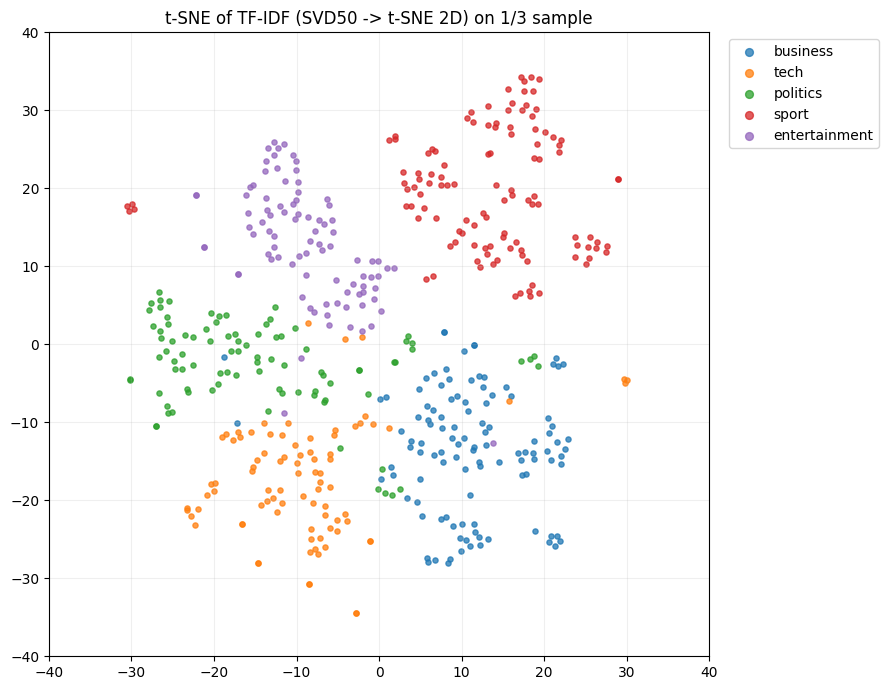

In [9]:
# Projection of the TF‑IDF features: TruncatedSVD (PCA-like) and t‑SNE
def plot_embedding(Z, labels, title, category_to_id):
    plt.figure(figsize=(9, 7))
    for cat, cid in category_to_id.items():
        mask = (labels == cid)
        plt.scatter(Z[mask, 0], Z[mask, 1], s=14, alpha=0.75, label=cat)
    plt.title(title)
    plt.xlim(-40, 40)
    plt.ylim(-40, 40)
    plt.grid(True, alpha=0.2)
    plt.legend(markerscale=1.5, bbox_to_anchor=(1.02, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# t‑SNE on a 1/3 sample (speed): SVD(50) -> t‑SNE(2)
idx = np.arange(len(train_df))
_, sample_idx = train_test_split(
    idx, test_size=0.33, random_state=RANDOM_STATE, stratify=train_df['Category']
)
X_sample = X[sample_idx]
y_sample = y.iloc[sample_idx].values

svd50 = TruncatedSVD(n_components=50, random_state=RANDOM_STATE)  # speed + denoise
X50 = svd50.fit_transform(X_sample)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate='auto',
    init='pca',
    random_state=RANDOM_STATE,
    metric='euclidean',
    verbose=0,
)
Z_tsne = tsne.fit_transform(X50)
plot_embedding(Z_tsne, y_sample, 't‑SNE of TF‑IDF (SVD50 -> t‑SNE 2D) on 1/3 sample', category_to_id)

### Step 2

### Building and training models

In the Kaggle competition, the training data has labels (category). Thus, it can be solved using supervised learning. In general, the more labeled data we have, the more accurate the supervised learning model will be. But unsupervised learning can be powerful even when there is a small number of labels or no labels. This assignment will apply an unsupervised approach, especially the matrix factorization method, to discover topics in the news articles and use the labels to check the accuracy.

Here are some steps to guide this section: 
1) Think about this and answer: when you train the unsupervised model for matrix factorization, should you include texts (word features) from the test dataset or not as the input matrix? Why or why not?
2) Build a model using the matrix factorization method(s) and predict the train and test data labels. Choose any hyperparameter (e.g., number of word features) to begin with.
3) Measure the performances on predictions from both train and test datasets. You can use accuracy, confusion matrix, etc., to inspect the performance. You can get accuracy for the test data by submitting the result to Kaggle. 
4) Change hyperparameter(s) and record the results. We recommend including a summary table and/or graphs.
5) Improve the model performance if you can- some ideas may include but are not limited to; using different feature extraction methods, fit models in different subsets of data, ensemble the model prediction results, etc. 

NMF topics=5 — Train accuracy: 0.9685

               precision    recall  f1-score   support

     business       0.97      0.95      0.96       336
         tech       0.94      0.96      0.95       261
     politics       0.96      0.97      0.96       274
        sport       0.99      1.00      1.00       346
entertainment       0.97      0.96      0.97       273

     accuracy                           0.97      1490
    macro avg       0.97      0.97      0.97      1490
 weighted avg       0.97      0.97      0.97      1490



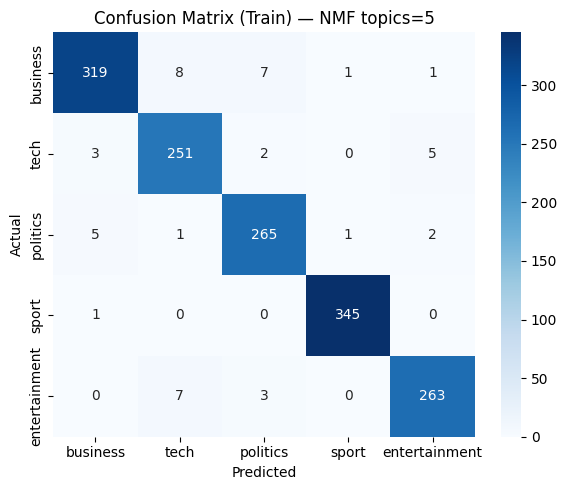

In [10]:
X_train = tfidf.fit_transform(train_df['processed_text'])
X_test = tfidf.transform(test_df['processed_text'])

y_train = train_df['category_id'].values

# Fit NMF topics on train only
n_topics = 5  # hyperparameter to tune!
# NMF topics=5 — Train accuracy: 0.9685
# NMF topics=6 — Train accuracy: 0.9383
# NMF topics=8 — Train accuracy: 0.9396
# NMF topics=10 — Train accuracy: 0.9094
# NMF topics=15 — Train accuracy: 0.9289
# NMF topics=25 — Train accuracy: 0.9101
# NMF topics=50 — Train accuracy: 0.8362
# NMF topics=75 — Train accuracy: 0.8221
# NMF topics=100 — Train accuracy: 0.7940

nmf = NMF(n_components=n_topics, init='nndsvda', beta_loss='kullback-leibler', solver='mu',
          max_iter=400, random_state=RANDOM_STATE, alpha_W=0.0, alpha_H=0.0, l1_ratio=0.0)
W_train = nmf.fit_transform(X_train)     # [n_docs, n_topics]
H = nmf.components_                      # [n_topics, n_terms]

# Normalize W rows to sum to 1 (topic mixture per doc)
W_train_norm = W_train / (W_train.sum(axis=1, keepdims=True) + 1e-12)

# Compute P(label | topic) from train
n_classes = len(id_to_category)
P_label_given_topic = np.zeros((n_topics, n_classes))
for c in range(n_classes):
    mask = (y_train == c)
    # Sum topic mass over docs of class c
    class_topic_mass = W_train_norm[mask].sum(axis=0)  # [n_topics]
    P_label_given_topic[:, c] = class_topic_mass

# Normalize over labels for each topic
P_label_given_topic = P_label_given_topic / (P_label_given_topic.sum(axis=1, keepdims=True) + 1e-12)  # [n_topics, n_classes]

# Predict labels for train and test using topic mixtures
def predict_from_W(W):
    Wn = W / (W.sum(axis=1, keepdims=True) + 1e-12)
    # Score for each class = topic mixture dot P(label|topic)
    scores = Wn @ P_label_given_topic  # [n_docs, n_classes]
    return scores.argmax(axis=1)

y_pred_train = predict_from_W(W_train)

W_test = nmf.transform(X_test)
y_pred_test = predict_from_W(W_test)


# Metrics on train; optional if test labels exist locally
acc_train = accuracy_score(y_train, y_pred_train)
cm_train = confusion_matrix(y_train, y_pred_train)
print(f"NMF topics={n_topics} — Train accuracy: {acc_train:.4f}\n")
print(classification_report(y_train, y_pred_train, target_names=[id_to_category[i] for i in range(n_classes)]))

plt.figure(figsize=(6,5))
sns.heatmap(cm_train, annot=True, fmt='d', cmap='Blues',
            xticklabels=[id_to_category[i] for i in range(n_classes)],
            yticklabels=[id_to_category[i] for i in range(n_classes)])
plt.title(f'Confusion Matrix (Train) — NMF topics={n_topics}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()

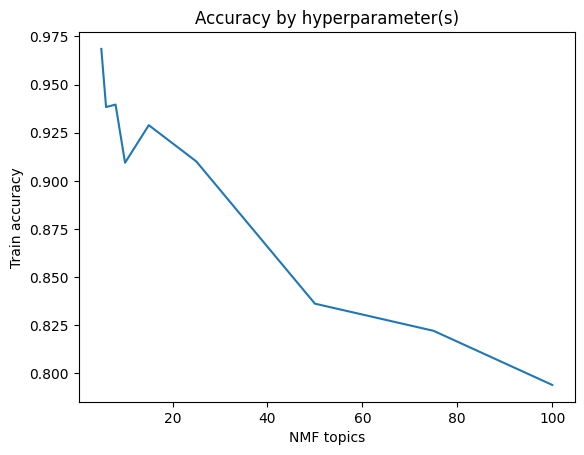

In [11]:
nmf_topics = [
    5, 
    6, 
    8, 
    10, 
    15,
    25,
    50,
    75,
    100]
train_accuracy = [
    0.9685, 
    0.9383, 
    0.9396, 
    0.9094, 
    0.9289,
    0.9101,
    0.8362,
    0.8221,
    0.7940
]

# Create the plot
plt.plot(nmf_topics, train_accuracy)
plt.xlabel("NMF topics")
plt.ylabel("Train accuracy")
plt.title("Accuracy by hyperparameter(s)")

# Display the plot
plt.show()

In [12]:
# Build submission for Kaggle
def get_test_ids(df):
    # Try common id columns; fallback to index
    for col in ['Id', 'ID', 'ArticleId', 'ArticleID', 'id']:
        if col in df.columns:
            return df[col].values, col
    return df.index.values, 'Id'

test_ids, id_col = get_test_ids(test_df)
sub = pd.DataFrame({
    id_col: test_ids,
    'Category': [id_to_category[i] for i in y_pred_test]
})
sub_path = 'kaggle_submission.csv'
sub.to_csv(sub_path, index=False)
print(f"Saved submission to {sub_path} with {len(sub)} rows.")

Saved submission to kaggle_submission.csv with 735 rows.


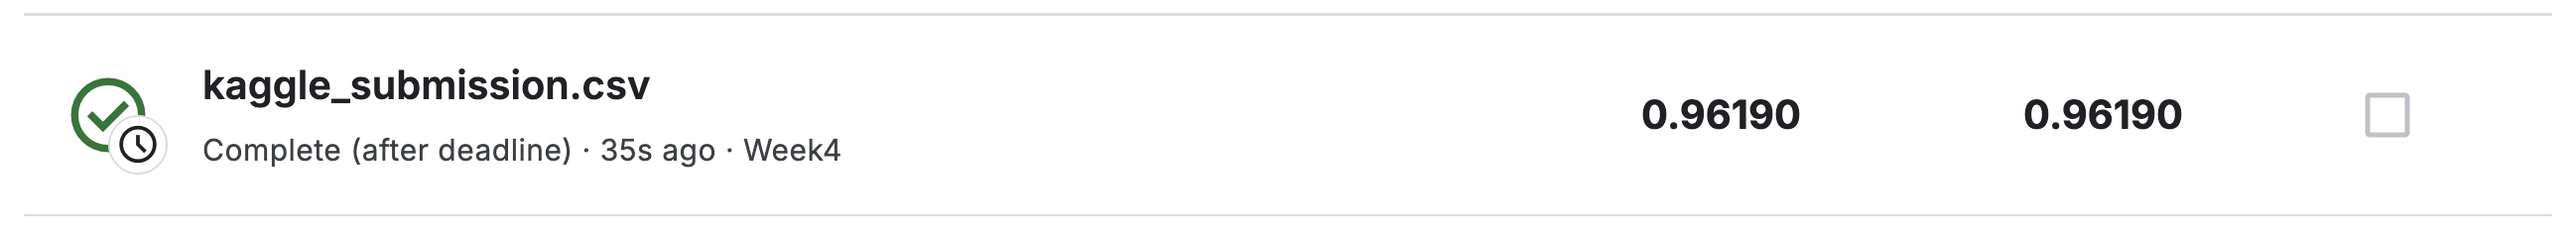

,n_topics,train_acc
0,5,0.968456
1,10,0.909396
2,15,0.928859
3,20,0.908725
4,25,0.910067
5,30,0.899329
6,35,0.890604
7,40,0.871812
8,45,0.861074
9,50,0.836242


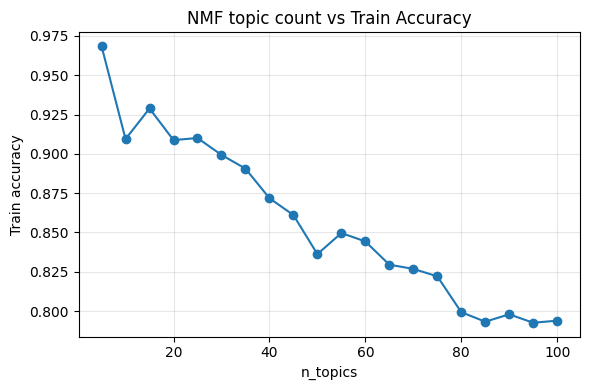

In [13]:
def eval_nmf(n_topics=50):
    ytr = y_train
    nm = NMF(n_components=n_topics, init='nndsvda', beta_loss='kullback-leibler', solver='mu',
             max_iter=300, random_state=RANDOM_STATE)
    Wtr = nm.fit_transform(X_train)
    # Normalize W rows to sum to 1 (topic mixture per doc)
    Wtr = Wtr / (Wtr.sum(axis=1, keepdims=True) + 1e-12)
    
    classes = np.unique(ytr)
    P_label_given_topic = np.zeros((n_topics, n_classes))
    for c in classes:
        P_label_given_topic[:, c] = Wtr[ytr==c].sum(axis=0)
    P_label_given_topic = P_label_given_topic / (P_label_given_topic.sum(axis=1, keepdims=True) + 1e-12)
    yhat = (Wtr @ P_label_given_topic).argmax(axis=1)
    acc = accuracy_score(ytr, yhat)
    return acc

results = []
for k in range(5, 101, 5): # For submission ONLY! 
# for k in range(5, 11, 5):
    acc = eval_nmf(n_topics=k)
    results.append({'n_topics': k, 'train_acc': acc})

res_df = pd.DataFrame(results)
display(res_df)

plt.figure(figsize=(6,4))
plt.plot(res_df['n_topics'], res_df['train_acc'], marker='o')
plt.title('NMF topic count vs Train Accuracy')
plt.xlabel('n_topics')
plt.ylabel('Train accuracy')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Step 3

### Compare with supervised learning

Use the following steps to guide your work:

1) Pick and train a supervised learning method(s) and compare the results (train and test performance)
2) Discuss comparison with the unsupervised approach. You may try changing the train data size (e.g., Include only 10%, 20%, 50% of labels, and observe train/test performance changes). Which methods are data-efficient (require a smaller amount of data to achieve similar results)? What about overfitting?

In [14]:
# Fixed validation split from train to estimate generalization
splitter = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)
(train_idx, val_idx), = splitter.split(train_df['Text'], train_df['Category'])

X_train_full = train_df.iloc[train_idx]['Text'].values
y_train_full = train_df.iloc[train_idx]['Category'].values
X_val = train_df.iloc[val_idx]['Text'].values
y_val = train_df.iloc[val_idx]['Category'].values
candidates = {
    'LinearSVC': LinearSVC(C=1.0, random_state=42),
    'LogReg': LogisticRegression(max_iter=2000, n_jobs=None, solver='lbfgs'),
    'MultinomialNB': MultinomialNB(alpha=0.1),
    'RandomForest': RandomForestClassifier(
        n_estimators=400,
        max_depth=None,
        n_jobs=-1,
        random_state=42,
        class_weight='balanced_subsample'
    )
}

results = []
best_name, best_model, best_val = None, None, -1

for name, clf in candidates.items():
    pipe = Pipeline([
        ('tfidf', tfidf),
        ('clf', clf),
    ])
    pipe.fit(X_train_full, y_train_full)
    # Train acc (on the training subset used to fit)
    y_pred_tr = pipe.predict(X_train_full)
    acc_tr = accuracy_score(y_train_full, y_pred_tr)
    # Validation acc
    y_pred_val = pipe.predict(X_val)
    acc_val = accuracy_score(y_val, y_pred_val)
    results.append((name, acc_tr, acc_val))
    if acc_val > best_val:
        best_name, best_model, best_val = name, pipe, acc_val

print("Supervised baselines (train_acc, val_acc):")
for name, acc_tr, acc_val in results:
    print(f"- {name}: train={acc_tr:.4f}, val={acc_val:.4f}")

print(f"\nBest model: {best_name} (val_acc={best_val:.4f})")
print("\nValidation classification report:")
print(classification_report(y_val, best_model.predict(X_val)))

Supervised baselines (train_acc, val_acc):
- LinearSVC: train=1.0000, val=0.9732
- LogReg: train=0.9975, val=0.9732
- MultinomialNB: train=0.9966, val=0.9832
- RandomForest: train=1.0000, val=0.9564

Best model: MultinomialNB (val_acc=0.9832)

Validation classification report:
               precision    recall  f1-score   support

     business       1.00      0.97      0.98        67
entertainment       0.98      1.00      0.99        55
     politics       0.96      0.96      0.96        55
        sport       1.00      1.00      1.00        69
         tech       0.96      0.98      0.97        52

     accuracy                           0.98       298
    macro avg       0.98      0.98      0.98       298
 weighted avg       0.98      0.98      0.98       298

